最新数据日期：2024-01-12
             open   high    low  close      volume
2024-01-08  16.57  17.18  16.40  16.50  17940754.0
2024-01-09  16.30  16.67  15.88  16.17  16787551.0
2024-01-10  16.15  16.42  15.65  16.28  13376237.0
2024-01-11  15.95  16.63  15.61  16.44  15052368.0
2024-01-12  16.30  16.99  16.19  16.19  16338219.0
检测结果统计 (窗口大小: 7)
普通高点数量: 4
普通低点数量: 3
极高点数量: 0
极低点数量: 1
总高点: 4, 总低点: 4


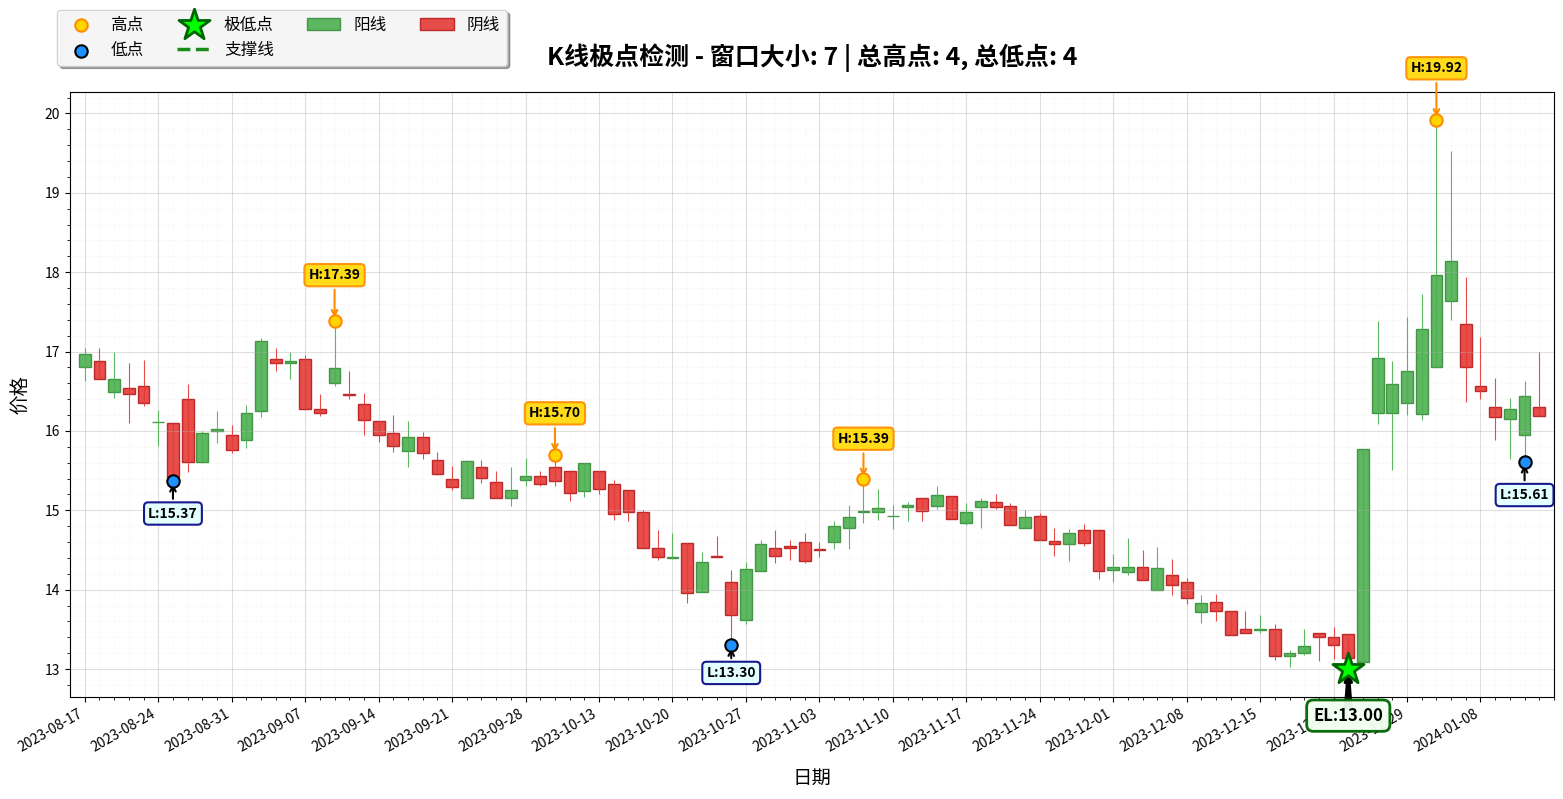

In [1]:
# 完整技术分析看盘程序 v1.0

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
import argparse
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from matplotlib.dates import DateFormatter
from matplotlib.patches import Rectangle
from scipy.signal import find_peaks
from scipy.stats import linregress

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from scipy.signal import argrelextrema



def detect_high_low_points(df, window=5):
    """
    可靠检测高点和低点极点，并在原始DataFrame中标记相关信息
    
    :param df: 包含价格数据的DataFrame（必须有'high'和'low'列）
    :param window: 检测窗口大小（数据点）
    :return: 增强后的DataFrame，包含新列：
        - 'is_high': 是否是高点
        - 'is_low': 是否是低点
        - 'is_extreme_high': 是否是极高点（比相邻高点都高）
        - 'is_extreme_low': 是否是极低点（比相邻低点都低）
        - 'prev_high_index': 前一个高点的索引位置
        - 'prev_low_index': 前一个低点的索引位置
        - 'prev_high_price': 前一个高点的价格
        - 'prev_low_price': 前一个低点的价格
    """
    # 确保必要的列存在
    if 'high' not in df.columns or 'low' not in df.columns:
        raise ValueError("DataFrame必须包含'high'和'low'列")
    
    # 获取价格序列
    high_prices = df['high'].values
    low_prices = df['low'].values
    
    # 检测高点（局部最大值）
    high_indices = argrelextrema(high_prices, np.greater, order=window)[0]
    # 检测低点（局部最小值）
    low_indices = argrelextrema(low_prices, np.less, order=window)[0]
    
    # 创建标记列
    df = df.copy()
    df['is_high'] = False
    df['is_low'] = False
    df['is_extreme_high'] = False
    df['is_extreme_low'] = False
    
    # 标记高点和低点
    df.loc[df.index[high_indices], 'is_high'] = True
    df.loc[df.index[low_indices], 'is_low'] = True
    
    # 检测极高点
    if len(high_indices) >= 3:
        for i in range(1, len(high_indices) - 1):
            prev_idx = high_indices[i-1]
            current_idx = high_indices[i]
            next_idx = high_indices[i+1]
            
            current_high = high_prices[current_idx]
            prev_high = high_prices[prev_idx]
            next_high = high_prices[next_idx]
            
            if current_high > prev_high and current_high > next_high:
                df.loc[df.index[current_idx], 'is_extreme_high'] = True
    
    # 检测极低点
    if len(low_indices) >= 3:
        for i in range(1, len(low_indices) - 1):
            prev_idx = low_indices[i-1]
            current_idx = low_indices[i]
            next_idx = low_indices[i+1]
            
            current_low = low_prices[current_idx]
            prev_low = low_prices[prev_idx]
            next_low = low_prices[next_idx]
            
            if current_low < prev_low and current_low < next_low:
                df.loc[df.index[current_idx], 'is_extreme_low'] = True
    
    # 创建前一个高点和低点的信息列
    df['prev_high_index'] = np.nan
    df['prev_high_price'] = np.nan
    df['prev_low_index'] = np.nan
    df['prev_low_price'] = np.nan
    
    # 初始化前一个高点和低点信息
    prev_high_index = None
    prev_high_price = None
    prev_low_index = None
    prev_low_price = None
    
    # 遍历DataFrame，记录前一个高点和低点信息
    for i, (index, row) in enumerate(df.iterrows()):
        # 记录前一个高点和低点信息
        if prev_high_index is not None:
            df.at[index, 'prev_high_index'] = prev_high_index
            df.at[index, 'prev_high_price'] = prev_high_price
        
        if prev_low_index is not None:
            df.at[index, 'prev_low_index'] = prev_low_index
            df.at[index, 'prev_low_price'] = prev_low_price
        
        # 如果当前点是高点，更新前一个高点信息
        if row['is_high']:
            prev_high_index = index
            prev_high_price = row['high']
        
        # 如果当前点是低点，更新前一个低点信息
        if row['is_low']:
            prev_low_index = index
            prev_low_price = row['low']
    
    return df


    
def plot_kline_with_extremes(df, window=5, save_path=None):
    """
    绘制K线图并标记高点和低点，包括极高点和极低点
    
    :param df: 包含价格数据的DataFrame（必须有'open', 'high', 'low', 'close'列）
    :param window: 极点检测窗口大小
    :param save_path: 图片保存路径（可选）
    """
    # 确保数据格式正确
    required_columns = ['open', 'high', 'low', 'close']
    if not all(col in df.columns for col in required_columns):
        raise ValueError("DataFrame必须包含'open', 'high', 'low', 'close'列")
    
    # 检测所有类型的极点
    df = detect_high_low_points(df, window=window)
    
    # 创建更大的图表
    plt.figure(figsize=(16, 8))
    ax = plt.gca()
    
    # 创建数值索引
    x = np.arange(len(df))
    
    # ------ 绘制K线 ------
    # 分离阳线和阴线
    up = df[df.close >= df.open]
    down = df[df.close < df.open]
    
    # 阳线 (现代绿色)
    if not up.empty:
        up_x = x[df.index.isin(up.index)]
        # 绘制影线
        ax.vlines(up_x, up.low, up.high, color='#4CAF50', linewidth=0.8, alpha=0.9)
        # 绘制实体
        ax.bar(up_x, up.close - up.open, 0.8, up.open, 
               color='#4CAF50', edgecolor='#388E3C', alpha=0.9, label='阳线')
    
    # 阴线 (现代红色)
    if not down.empty:
        down_x = x[df.index.isin(down.index)]
        # 绘制影线
        ax.vlines(down_x, down.low, down.high, color='#E53935', linewidth=0.8, alpha=0.9)
        # 绘制实体
        ax.bar(down_x, down.close - down.open, 0.8, down.open, 
               color='#E53935', edgecolor='#B71C1C', alpha=0.9, label='阴线')
    
    # 统计各类极点数量
    normal_highs = df[df['is_high'] & ~df['is_extreme_high']]
    normal_lows = df[df['is_low'] & ~df['is_extreme_low']]
    extreme_highs = df[df['is_extreme_high']]
    extreme_lows = df[df['is_extreme_low']]
    
    total_highs = len(normal_highs) + len(extreme_highs)
    total_lows = len(normal_lows) + len(extreme_lows)
    
    print(f"检测结果统计 (窗口大小: {window})")
    print(f"普通高点数量: {len(normal_highs)}")
    print(f"普通低点数量: {len(normal_lows)}")
    print(f"极高点数量: {len(extreme_highs)}")
    print(f"极低点数量: {len(extreme_lows)}")
    print(f"总高点: {total_highs}, 总低点: {total_lows}")
    print("="*50)
    
    # 标记检测到的普通高点 - 金色圆形 (带箭头)
    if not normal_highs.empty:
        normal_highs_x = x[df.index.isin(normal_highs.index)]
        for i, (xi, price) in enumerate(zip(normal_highs_x, normal_highs['high'])):
            # 绘制标记
            ax.scatter(
                xi, price, 
                marker='o', color='gold', s=80,  # 圆形
                edgecolors='darkorange', linewidth=1.5,
                zorder=100,
                label='高点' if i == 0 else None
            )
            # 添加价格标签带箭头
            ax.annotate(
                f'H:{price:.2f}',
                xy=(xi, price),
                xytext=(xi, price * 1.03),
                arrowprops=dict(
                    arrowstyle='->', 
                    color='darkorange',
                    linewidth=1.5
                ),
                ha='center',
                fontsize=10,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="gold", alpha=0.9, ec="darkorange", lw=1.5)
            )
    
    # 标记检测到的普通低点 - 蓝色圆形 (带箭头)
    if not normal_lows.empty:
        normal_lows_x = x[df.index.isin(normal_lows.index)]
        for i, (xi, price) in enumerate(zip(normal_lows_x, normal_lows['low'])):
            ax.scatter(
                xi, price, 
                marker='o', color='dodgerblue', s=80,  # 圆形
                edgecolors='black', linewidth=1.5,
                zorder=100,
                label='低点' if i == 0 else None
            )
            # 添加价格标签带箭头
            ax.annotate(
                f'L:{price:.2f}',
                xy=(xi, price),
                xytext=(xi, price * 0.97),
                arrowprops=dict(
                    arrowstyle='->', 
                    color='black',
                    linewidth=1.5
                ),
                ha='center',
                fontsize=10,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="lightcyan", alpha=0.9, ec="navy", lw=1.5)
            )
    
    # 标记检测到的极高点 - 红色五角星 (带箭头)
    if not extreme_highs.empty:
        extreme_highs_x = x[df.index.isin(extreme_highs.index)]
        for i, (xi, price) in enumerate(zip(extreme_highs_x, extreme_highs['high'])):
            # 绘制标记
            ax.scatter(
                xi, price, 
                marker='*', color='red', s=550,  # 五角星
                edgecolors='black', linewidth=2.0,
                zorder=101,
                label='极高点' if i == 0 else None
            )
            # 添加价格标签带箭头
            ax.annotate(
                f'EH:{price:.2f}',
                xy=(xi, price),
                xytext=(xi, price * 1.05),
                arrowprops=dict(
                    arrowstyle='fancy', 
                    color='black',
                    linewidth=2.0,
                    shrinkA=5, shrinkB=5,
                    patchA=None,
                    patchB=None,
                    relpos=(0.5, 0.5)
                ),
                ha='center',
                fontsize=12,
                fontweight='bold',
                color='black',
                bbox=dict(boxstyle="round,pad=0.4", fc="mistyrose", alpha=0.95, ec="darkred", lw=2)
            )
    
    # 标记检测到的极低点 - 绿色五角星 (带箭头)
    if not extreme_lows.empty:
        extreme_lows_x = x[df.index.isin(extreme_lows.index)]
        for i, (xi, price) in enumerate(zip(extreme_lows_x, extreme_lows['low'])):
            ax.scatter(
                xi, price, 
                marker='*', color='lime', s=550,  # 五角星
                edgecolors='darkgreen', linewidth=2.0,
                zorder=101,
                label='极低点' if i == 0 else None
            )
            # 添加价格标签带箭头
            ax.annotate(
                f'EL:{price:.2f}',
                xy=(xi, price),
                xytext=(xi, price * 0.95),
                arrowprops=dict(
                    arrowstyle='fancy', 
                    color='black',
                    linewidth=2.0,
                    shrinkA=5, shrinkB=5,
                    patchA=None,
                    patchB=None,
                    relpos=(0.5, 0.5)
                ),
                ha='center',
                fontsize=12,
                fontweight='bold',
                color='black',
                bbox=dict(boxstyle="round,pad=0.4", fc="honeydew", alpha=0.95, ec="darkgreen", lw=2)
            )
    
    # 添加趋势线（连接极高点和极低点）
    if not extreme_highs.empty:
        extreme_highs_x = x[df.index.isin(extreme_highs.index)]
        ax.plot(extreme_highs_x, extreme_highs['high'], 'r--', alpha=0.9, linewidth=2.5, label='阻力线')
    
    if not extreme_lows.empty:
        extreme_lows_x = x[df.index.isin(extreme_lows.index)]
        ax.plot(extreme_lows_x, extreme_lows['low'], 'g--', alpha=0.9, linewidth=2.5, label='支撑线')
    
    # 添加标题
    plt.title(
        f'K线极点检测 - 窗口大小: {window} | 总高点: {total_highs}, 总低点: {total_lows}',
        fontsize=18,
        fontweight='bold',
        pad=20
    )
    
    # 设置X轴范围
    ax.set_xlim(-1, len(df))
    
    # 设置网格
    ax.grid(True, which='major', linestyle='-', alpha=0.4, linewidth=0.8)
    ax.grid(True, which='minor', linestyle=':', alpha=0.2, linewidth=0.5)
    ax.minorticks_on()
    
    # 设置Y轴标签
    ax.set_ylabel('价格', fontsize=14, labelpad=10)
    
    # 设置X轴标签
    if isinstance(df.index, pd.DatetimeIndex):
        # 设置日期格式
        max_ticks = min(20, len(df))
        step = max(1, len(df) // max_ticks)
        ax.set_xticks(range(0, len(df), step))
        ax.set_xticklabels([df.index[i].strftime('%Y-%m-%d') for i in range(0, len(df), step)])
        plt.gcf().autofmt_xdate()
        ax.set_xlabel('日期', fontsize=14, labelpad=10)
    else:
        ax.set_xlabel('数据点索引', fontsize=14, labelpad=10)
    
    # 添加图例
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    ax.legend(unique_labels.values(), unique_labels.keys(), 
              loc='upper right', 
              bbox_to_anchor=(0.3, 1.15),
              ncol=4, 
              fontsize=12,
              frameon=True,
              framealpha=0.9,
              shadow=True)
    
    plt.tight_layout()    
    plt.savefig('kline_extremes.png', dpi=300, bbox_inches='tight')
    plt.show()

    
    
    



    


# ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='300505.SZ',     # 默认证券代码
        help='Stock code (default: 300032.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        #end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        end_date='20240112',  # 结束日期设为今天
        fre_step='1d',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=100,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
   
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    # 调用函数
    plot_kline_with_extremes(df, window=7)
    
    
    